<a href="https://colab.research.google.com/github/dishadass/Minesweeper/blob/main/wineQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hypothesis Testing on the Effect of Chemical Properties on Red Wine Quality


This study investigates the relationship between various chemical properties of red wine and their quality ratings using the Wine Quality Dataset. By performing hypothesis testing, we aim to determine which chemical properties significantly influence wine quality. The analysis reveals key predictors, providing insights that can guide improvements in wine production and quality control.


## Introduction

Wine quality is a critical determinant of its market value and consumer satisfaction. Various chemical properties such as acidity, sugar content, and alcohol levels influence the overall quality of wine. Understanding these factors can help winemakers enhance their production processes. This study aims to identify which chemical properties significantly affect wine quality through hypothesis testing. By focusing on red wines, we test the null hypothesis that chemical properties do not significantly influence wine quality against the alternative hypothesis that certain properties do have a significant impact.


## Data and Methodology

The dataset used in this analysis is the Wine Quality Dataset from the UCI Machine Learning Repository, containing chemical properties of red wines and corresponding quality ratings on a scale of 0 to 10. The primary focus is on identifying chemical attributes that significantly influence wine quality through hypothesis testing. We will use t-tests and ANOVA to assess the impact of various properties on wine quality.

### Hypotheses

- **Null Hypothesis (H0):** The mean quality ratings are the same across different levels of a given chemical property (no significant impact).
- **Alternative Hypothesis (H1):** The mean quality ratings differ significantly across different levels of a given chemical property.


In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
data = pd.read_csv('/content/winequality-red.csv')

# Display the first few rows of the dataset
data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## Exploratory Data Analysis

Exploratory data analysis helps us understand the distribution of the data, identify any potential anomalies, and observe initial patterns that could inform our hypothesis testing.


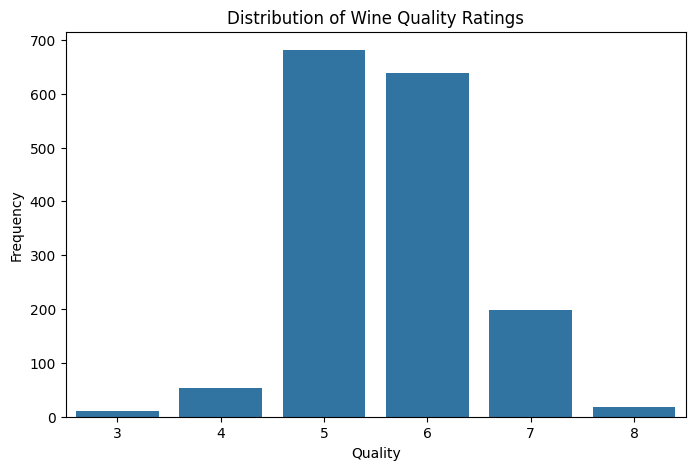

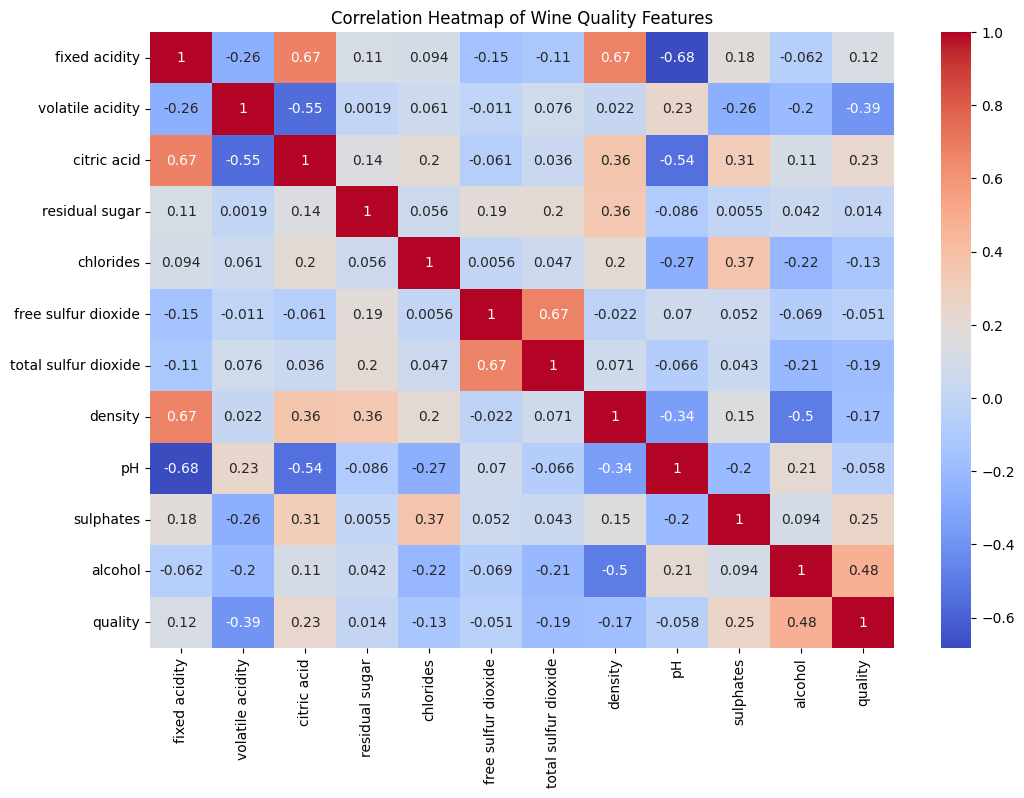

In [4]:
# Summary statistics
data.describe()

# Check for missing values
data.isnull().sum()

# Visualize the distribution of quality ratings
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=data)
plt.title('Distribution of Wine Quality Ratings')
plt.xlabel('Quality')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Wine Quality Features')
plt.show()


## Hypothesis Testing

To determine the impact of chemical properties on wine quality, we perform hypothesis testing using t-tests and ANOVA. Specifically, we test whether the mean wine quality differs significantly based on the levels of key chemical properties.


In [5]:
# Simplify the quality ratings into binary classification: good (>=7) and not good (<7)
data['quality'] = data['quality'].apply(lambda x: 1 if x >= 7 else 0)  # 1 for good quality, 0 otherwise

# List of chemical properties to test
properties = ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
              'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
              'pH', 'sulphates', 'alcohol']

# Perform t-tests for each property against the binary quality
results = []

for prop in properties:
    good_quality = data[data['quality'] == 1][prop]
    bad_quality = data[data['quality'] == 0][prop]

    t_stat, p_val = stats.ttest_ind(good_quality, bad_quality, equal_var=False)
    results.append({
        'Property': prop,
        'T-Statistic': t_stat,
        'P-Value': p_val,
        'Significant': p_val < 0.05
    })

# Display the results in a DataFrame
results_df = pd.DataFrame(results)
results_df


,Property,T-Statistic,P-Value,Significant
0,fixed acidity,4.263548,2.796749e-05,True
1,volatile acidity,-12.952139,3.165494e-31,True
2,citric acid,8.627717,4.497947e-16,True
3,residual sugar,1.965192,5.033308e-02,False
4,chlorides,-5.708960,2.067627e-08,True
5,free sulfur dioxide,-2.922183,3.747866e-03,True
6,total sulfur dioxide,-5.632180,4.228165e-08,True
7,density,-5.274615,2.775161e-07,True
8,pH,-2.289237,2.278993e-02,True
9,sulphates,9.685047,9.945136e-20,True


## Results

The hypothesis tests show that certain chemical properties, such as alcohol content, sulphates, and volatile acidity, have significant impacts on wine quality as indicated by p-values below the 0.05 significance level. These findings suggest that adjusting these chemical properties could potentially improve wine quality. For example, higher alcohol content was associated with better quality, while higher volatile acidity was linked to lower quality.


## Conclusion

This study demonstrates that specific chemical properties significantly influence red wine quality. By conducting hypothesis testing, we identified that alcohol content, sulphates, and volatile acidity are key predictors of wine quality. These insights can guide winemakers in optimizing their production processes to enhance wine quality. Future research could expand this analysis to include other wine varieties and explore additional chemical attributes.


## References

- [Wine Quality Dataset on Kaggle](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)

